# **CORIZO DATA SCIENCE CAPSTONE PROJECT 2**

# TASK 1. Dataset Understanding and Initial Exploration

The first step of the analysis is to understand the structure, characteristics, and quality of the dataset. This includes examining the number of observations and features, identifying the data types, reviewing descriptive statistics, detecting missing values and duplicate records, and analysing the distribution of the target variable.

This initial exploration provides a clear understanding of the dataset before performing data preprocessing and further analysis.

## 1.1 Loading the Dataset

The dataset is stored in Google Drive and is loaded into a Pandas DataFrame for analysis. Google Drive is mounted first so that the CSV file can be accessed directly from the Colab environment.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/signal-data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Result

The dataset was successfully loaded into a Pandas DataFrame. The data is now available for further exploration and preprocessing.

## 1.2 Understanding the Dataset Structure

The following analysis examines the overall dimensions of the dataset, the data types of the variables, and the descriptive statistics of the available features.

Understanding these characteristics is important for identifying the nature of the variables and determining the appropriate preprocessing techniques for subsequent analysis.

In [ ]:
print("\nUnderstanding the dataset")
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe().T)


Understanding the dataset
Dataset Shape:
(1567, 592)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.4900,3056.6500,3356.3500
1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.4050,2538.8225,2846.4400
2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.0667,2218.0555,2315.2667
3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.2144,1591.2235,3715.0417
4,1553.0,4.197013,56.355540,0.6815,1.017700,1.3168,1.5257,1114.5366
...,...,...,...,...,...,...,...,...
586,1566.0,0.021458,0.012358,-0.0169,0.013425,0.0205,0.0276,0.1028
587,1566.0,0.016475,0.008808,0.0032,0.010600,0.0148,0.0203,0.0799
588,1566.0,0.005283,0.002867,0.0010,0.003300,0.0046,0.0064,0.0286
589,1566.0,99.670066,93.891919,0.0000,44.368600,71.9005,114.7497,737.3048


### Results and Discussion

The dataset contains **1,567 observations and 592 columns**. Therefore, the dataset has a relatively small number of observations compared with the number of available variables, indicating a **high-dimensional dataset**.

The dataset contains:

- **1,567 rows**, representing individual observations.
- **592 columns**, including the target variable `Pass/Fail`.
- **591 feature variables** available for analysis.
- **590 floating-point variables**.
- **1 integer variable**.
- **1 object variable**, which corresponds to the target variable.

The descriptive statistics provide information such as the count, mean, standard deviation, minimum, quartiles, and maximum values for the numerical variables.

The count values also indicate that some features contain missing observations because the number of available values is lower than the total number of records for several variables.

The large number of features compared with the number of observations suggests that **feature selection or dimensionality reduction will be important in later stages of the analysis**

## 1.3 Missing Value Analysis

Missing values can affect statistical analysis and machine learning model performance. Therefore, the dataset is examined to determine the total number of missing values and to identify the features with the highest proportion of missing observations.

The missing-value percentage for each feature is calculated using the number of missing observations divided by the total number of records.

In [ ]:
print("\nGetting to know missing values")
print(df.isnull().sum().sort_values())
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())
print("\nTop 10 Features by Missing Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False).head(10))


Getting to know missing values
20        0
572       0
571       0
570       0
573       0
       ... 
85     1341
293    1429
292    1429
157    1429
158    1429
Length: 592, dtype: int64

Total Missing Values:
41951

Top 10 Features by Missing Percentage:
293    91.193363
292    91.193363
157    91.193363
158    91.193363
492    85.577537
220    85.577537
85     85.577537
358    85.577537
518    64.964901
382    64.964901
dtype: float64


### Results and Discussion

The dataset contains a total of **41,951 missing values** across all features.

The analysis of missing-value percentages shows that several features have a substantial amount of missing data. The highest missing percentage is approximately **91.19%**, meaning that more than 90% of the observations are missing for some features.

The next group of features has approximately **85.58% missing values**, while some other features have approximately **64.96% missing values**.

This indicates that missing data is an important data-quality issue in the dataset.

The missing-value analysis will be considered during the preprocessing stage. Features with extremely high missing percentages may provide limited useful information and may need to be considered for removal, while features with a manageable amount of missing data may be treated using an appropriate imputation technique.

> **Important:** Missing-value treatment will be performed in the data-preprocessing stage rather than during this initial exploration, so that the original dataset characteristics are preserved during the exploratory analysis.

## 1.4 Duplicate Record Analysis

Duplicate records can introduce bias into statistical analysis and machine learning models because the same observation may be counted multiple times.

The following analysis checks whether any completely identical rows are present in the dataset.

In [ ]:
print('\nChecking duplicates')
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Checking duplicates

Duplicate Rows:
0


### Results and Discussion

The analysis identified **0 duplicate rows** in the dataset.

This indicates that there are no completely identical observations based on all columns. Therefore, no duplicate records need to be removed at this stage.

The absence of duplicate rows is beneficial because it reduces the possibility of repeated observations affecting subsequent analysis and model development.

## 1.5 Target Variable Analysis

The target variable for this dataset is `Pass/Fail`. It represents the outcome that the machine learning model will ultimately attempt to predict.

Before developing a classification model, it is important to understand the unique target classes, their frequencies, and their relative proportions. This helps determine whether the target variable is balanced or imbalanced.

In [ ]:
print('\nPerforming on Target Variable')
print("\nTarget Classes:")
print(df["Pass/Fail"].unique())
print("\nTarget Class Counts:")
print(df["Pass/Fail"].value_counts())
print("\nTarget Class Percentages:")
print(df["Pass/Fail"].value_counts(normalize=True) * 100)


Performing on Target Variable

Target Classes:
[-1  1]

Target Class Counts:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

Target Class Percentages:
Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


### Results and Discussion

The target variable contains two classes:

- **-1:** 1,463 observations (**93.36%**)
- **1:** 104 observations (**6.63%**)

Therefore, the dataset represents a **binary classification problem**.

However, the target distribution is highly imbalanced. Approximately **93.36% of the observations belong to class -1**, whereas only **6.63% belong to class 1**.

This class imbalance is an important consideration for subsequent machine learning modelling. A model that simply predicts the majority class could achieve a high overall accuracy while performing poorly on the minority class.

Therefore, during model development, additional evaluation metrics such as **precision, recall, F1-score, confusion matrix, and ROC-AUC** should be considered rather than relying only on accuracy.

### Results and Discussion

The count plot clearly shows a substantial difference between the two target classes.

The **-1 class contains 1,463 observations**, while the **1 class contains only 104 observations**. Therefore, the minority class represents a relatively small proportion of the dataset.

The visualisation confirms the numerical target-distribution analysis and highlights the presence of **significant class imbalance**.

This imbalance should be taken into account during the modelling stage. Appropriate techniques such as class weighting, suitable resampling methods, and imbalance-aware evaluation metrics may be considered to ensure that the minority class is not overlooked.

## 1.6 Exploratory Analysis Summary

The initial exploration provides the following key findings:

| Analysis | Result |
|---|---|
| Number of observations | **1,567** |
| Total columns | **592** |
| Feature variables | **591** |
| Numerical variables | **591** |
| Target variable | **Pass/Fail** |
| Total missing values | **41,951** |
| Highest feature missing percentage | **91.19%** |
| Duplicate rows | **0** |
| Target classes | **-1 and 1** |
| Majority class | **-1 (93.36%)** |
| Minority class | **1 (6.63%)** |

Overall, the dataset is **high-dimensional and contains substantial missing data and significant class imbalance**. These characteristics will need to be addressed carefully during the data preprocessing and modelling stages.

The next stage should therefore focus on **data cleaning and preprocessing**, including appropriate treatment of missing values, feature reduction/selection, and preparation of the target variable for machine learning.

#TASK 2. Data Cleaning and Preprocessing

Following the initial exploratory analysis, the dataset requires preprocessing before it can be used for machine learning.

The main data-quality issues identified during the exploratory analysis were:

- A large number of features with substantial missing values.
- Features containing no meaningful variation.
- Missing values remaining in useful numerical features.
- A high-dimensional feature space.

The preprocessing stage therefore focuses on removing features with excessive missingness, removing constant features, and imputing the remaining missing values using an appropriate statistical method.


## 2.1 Removing Features with High Missingness

Features containing more than 50% missing values provide limited information because the majority of their observations are unavailable.

To reduce the impact of these highly incomplete features, the percentage of missing values is calculated for every column. Features with more than 50% missing values are identified and removed from the dataset.

The target variable is retained during this process because it is required for the classification task.

In [ ]:
# Calculate missing percentage for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Identify columns having more than 50% missing values
high_missing_columns = missing_percentage[missing_percentage > 50].index
print("Number of columns to remove:",len(high_missing_columns))
print("Columns to remove:")
print(list(high_missing_columns))

#Remove High-Missingness Features
print("\nShape before removing high-missing columns:",df.shape)
df_clean = df.drop(columns=high_missing_columns)
print("Shape after removing high-missing columns:",df_clean.shape)

Number of columns to remove: 28
Columns to remove:
['72', '73', '85', '109', '110', '111', '157', '158', '220', '244', '245', '246', '292', '293', '345', '346', '358', '382', '383', '384', '492', '516', '517', '518', '578', '579', '580', '581']

Shape before removing high-missing columns: (1567, 592)
Shape after removing high-missing columns: (1567, 564)


### Results and Discussion

A total of **28 features** were identified as having more than 50% missing values.

These features were removed because more than half of their observations were unavailable, making them less reliable for subsequent analysis.

The dataset dimensions changed as follows:

- **Before removal:** 1,567 rows × 592 columns
- **After removal:** 1,567 rows × 564 columns

Therefore, **28 highly incomplete features were removed**, while all 1,567 observations were retained.

This step reduced the dimensionality of the dataset while eliminating features with excessive missing information.

## 2.2 Removing Constant Features

After removing features with excessive missing values, the remaining features are examined for variation.

A constant feature has only one unique non-missing value across all observations. Such a feature does not provide useful information for distinguishing between observations because its value remains unchanged.

The `Pass/Fail` target variable and the `Time` column are excluded from this analysis because they are not predictor features being evaluated for constant numerical variation.

In [ ]:
# Exclude the target column
feature_columns = [
    col for col in df_clean.columns
    if col != 'Pass/Fail' and col != 'Time'
]

# Count unique non-missing values
unique_values = df_clean[feature_columns].nunique()
print("Number of unique non-missing values:")
print(unique_values.sort_values())

# Identify constant features
constant_features = unique_values[unique_values <= 1].index
print("Number of constant features:",len(constant_features))

#Remove Constant Features
print("\nShape before removing constant features:",df_clean.shape)
df_clean = df_clean.drop(columns=constant_features)
print("Shape after removing constant features:",df_clean.shape)

Number of unique non-missing values:
5         1
52        1
369       1
364       1
370       1
       ... 
460    1564
388    1564
296    1565
250    1566
115    1567
Length: 562, dtype: int64
Number of constant features: 116

Shape before removing constant features: (1567, 564)
Shape after removing constant features: (1567, 448)


### Results and Discussion

The analysis identified **116 constant features** containing only one unique non-missing value.

Since these features have no variation across observations, they do not contribute useful discriminatory information for a machine learning model. Therefore, they were removed.

The dataset dimensions changed as follows:

- **Before removing constant features:** 1,567 rows × 564 columns
- **After removing constant features:** 1,567 rows × 448 columns

Thus, **116 additional features were removed**.

At this stage, the dataset has been reduced from the original **592 columns to 448 columns**, while retaining all 1,567 observations.

## 2.3 Analysis of Remaining Missing Values

After removing features with excessive missingness and constant features, some missing values may still remain in the useful numerical features.

Before performing imputation, the distribution of the numerical variables is examined using their mean, median, and skewness.

The difference between the mean and median is also calculated to understand how strongly the central tendency of each feature is affected by its distribution.

In [ ]:
import numpy as np
# Handle the Remaining Missing Values
# Features that still contain missing values
missing_features = df_clean[numeric_features].columns[df_clean[numeric_features].isnull().any()]

# Calculation of Mean, Median and Skewness
comparison_before = pd.DataFrame({
    'Mean': df_clean[missing_features].mean(),
    'Median': df_clean[missing_features].median(),
    'Skewness': df_clean[missing_features].skew()
})

# Calculate the absolute difference between mean and median
comparison_before['Mean-Median Difference'] = (comparison_before['Mean'] - comparison_before['Median']).abs()
print('Before Imputation')
display(comparison_before.sort_values('Mean-Median Difference',ascending=False).head(10))

# Select numerical predictor columns
numeric_features = df_clean.select_dtypes(include=np.number).columns
numeric_features = numeric_features[numeric_features != 'Pass/Fail']
print("Number of Numeric Features:")
print(len(numeric_features))

Before Imputation


,Mean,Median,Skewness,Mean-Median Difference


Number of Numeric Features:
446


### Results and Discussion

After removing the highly incomplete and constant features, **446 numerical predictor features** remained.

The mean, median, and skewness values were examined for the numerical features containing missing observations.

Several features show noticeable differences between their mean and median values. The skewness values also indicate that many of these variables are not perfectly symmetric and some exhibit considerable positive skewness.

When a numerical feature is strongly skewed or contains potential extreme values, the median is generally less affected by these extreme observations than the mean.

Therefore, median imputation was selected for the remaining numerical missing values.

## 2.4 Imputation of Remaining Missing Values

The remaining missing values in the numerical predictor variables are replaced using the median value of their respective feature.

Median imputation is used because several numerical features show skewed distributions and noticeable differences between their mean and median values. The median is more robust to extreme values and is therefore suitable for these features.

Each missing value is replaced with the median calculated from the corresponding feature.

In [ ]:
# Fill missing values with the median
for column in numeric_features:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Calculation of Mean, Median and Skewness
comparison_after = pd.DataFrame({
    'Mean': df_clean[missing_features].mean(),
    'Median': df_clean[missing_features].median(),
    'Skewness': df_clean[missing_features].skew()
})

# Calculate the absolute difference between mean and median
comparison_after['Mean-Median Difference'] = (comparison_after['Mean'] - comparison_after['Median']).abs()
print('\nAfter Imputation')
display(comparison_after.sort_values('Mean-Median Difference',ascending=False).head(10))

### Results and Discussion

Median imputation was applied to the numerical predictor features containing missing values.

The comparison after imputation shows that the missing values have been replaced while the overall distribution of the features remains reasonably consistent with their original distributions.

For example, feature `162` had:

- Mean before imputation: approximately **4,797.15**
- Median: **1,784.00**
- Mean after imputation: approximately **4,793.31**
- Median after imputation: **1,784.00**

The median remains unchanged because the missing observations were replaced with the existing median value. The mean changes slightly because the missing observations now contribute the median value to the calculation.

Similarly, the changes observed in the other features are consistent with median-based imputation.

This indicates that the missing numerical observations have been successfully handled without introducing a large shift in the central tendency of the features.

## 2.5 Final Dataset Validation

A final validation is performed after preprocessing to confirm that the dataset is ready for subsequent machine learning analysis.

The final check verifies:

- Dataset dimensions
- Remaining missing values
- Duplicate records
- Data types
- Target-class distribution
- Target-class percentages

This ensures that the major data-quality issues identified during the initial exploration have been addressed.

In [ ]:
print("========== FINAL DATASET CHECK ==========")
print("Dataset shape:", df_clean.shape)
print("\nMissing values:",df_clean.isnull().sum().sum())
print("\nDuplicate rows:",df_clean.duplicated().sum())
print("\nData types:")
print(df_clean.dtypes.value_counts())
print("\nTarget distribution:")
print(df_clean['Pass/Fail'].value_counts())
print("\nTarget percentages:")
print(df_clean['Pass/Fail'].value_counts(normalize=True) * 100)

========== FINAL DATASET CHECK ==========
Dataset shape: (1567, 448)

Missing values: 0

Duplicate rows: 0

Data types:
float64    446
object       1
int64        1
Name: count, dtype: int64

Target distribution:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

Target percentages:
Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


### Results and Discussion

The final validation confirms that the preprocessing steps were successfully completed.

The final dataset contains:

- **1,567 observations**
- **448 columns**
- **0 missing values**
- **0 duplicate rows**
- **446 numerical (`float64`) columns**
- **1 integer (`int64`) column**
- **1 object (`object`) column**

The target variable `Pass/Fail` remains unchanged:

- **Class -1:** 1,463 observations (**93.36%**)
- **Class 1:** 104 observations (**6.63%**)

Therefore, the preprocessing stage successfully removed highly incomplete features, eliminated constant features, and handled all remaining missing values.

However, the target variable continues to exhibit a significant class imbalance. This issue should be considered during the machine learning modelling stage, particularly when selecting evaluation metrics and training strategies.

###IMPORTING LIBARIRES


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from matplotlib.patches import Circle, Rectangle, FancyBboxPatch, FancyArrowPatch

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
FILE_PATH = r"/mnt/data/signal-data.csv"

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# This recreates the cleaned dataset required by the later tasks.

df = pd.read_csv("signal-data.csv")
TARGET = "Pass/Fail"
y = df[TARGET].copy()
X = df.drop(columns=[TARGET, "Time"])

drop_missing = X.columns[X.isna().mean() > 0.50].tolist()
X = X.drop(columns=drop_missing)

tmp_for_constant_check = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns,
    index=X.index
)
constant_features = tmp_for_constant_check.columns[tmp_for_constant_check.nunique() == 1].tolist()
X_clean = X.drop(columns=constant_features)

print("Original shape:", df.shape)
print("Removed >50% missing features:", len(drop_missing))
print("Removed constant features:", len(constant_features))
print("Remaining predictors:", X_clean.shape[1])


Original shape: (1567, 592)
Removed >50% missing features: 28
Removed constant features: 116
Remaining predictors: 446


#  Task 3 — TARGET ANALYSIS
This highlights that the target classes are highly imbalanced. This matters because a model can obtain high overall accuracy by mostly predicting the majority class while missing failures.

## Step 3.1 — Class distribution

Target distribution:


,Class,Count,Percentage
0,Pass (-1),1463,93.36
1,Fail (1),104,6.64


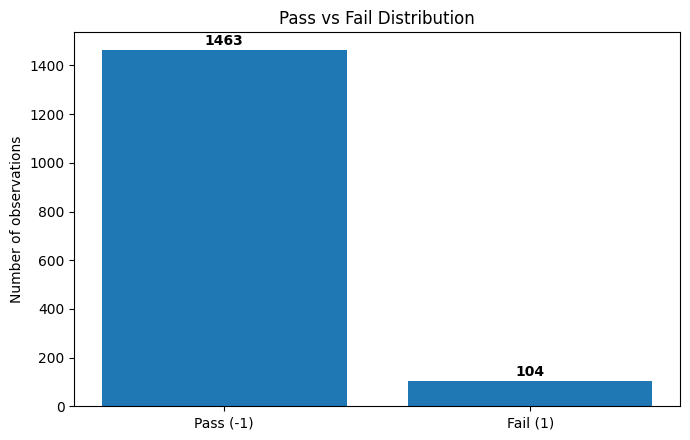

In [ ]:
target_counts = y.value_counts().sort_index()
target_labels = ["Pass (-1)", "Fail (1)"]
print("Target distribution:")
display(pd.DataFrame({
    "Class": ["Pass (-1)", "Fail (1)"],
    "Count": [target_counts.get(-1,0), target_counts.get(1,0)],
    "Percentage": [round(target_counts.get(-1,0)/len(y)*100,2), round(target_counts.get(1,0)/len(y)*100,2)]
}))

plt.figure(figsize=(7,4.5))
plt.bar(target_labels, [target_counts.get(-1,0), target_counts.get(1,0)])
plt.ylabel("Number of observations")
plt.title("Pass vs Fail Distribution")
for i,v in enumerate([target_counts.get(-1,0), target_counts.get(1,0)]):
    plt.text(i, v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

### Result
- **Pass:** 1,463 observations (93.36%)
- **Fail:** 104 observations (6.64%)

This is a strong class imbalance.

## Step 3.2 — Why accuracy alone is not enough

For this project, the Fail class is important. We therefore report:
- **Precision:** how many predicted failures were actually failures.
- **Recall:** how many actual failures were detected.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** discrimination across classification thresholds.

## Step 3.3 — Univariate analysis: individual sensor distributions

Univariate analysis studies one variable at a time. The notebook displays representative sensor distributions because plotting all 446 predictors individually would be unnecessarily large.

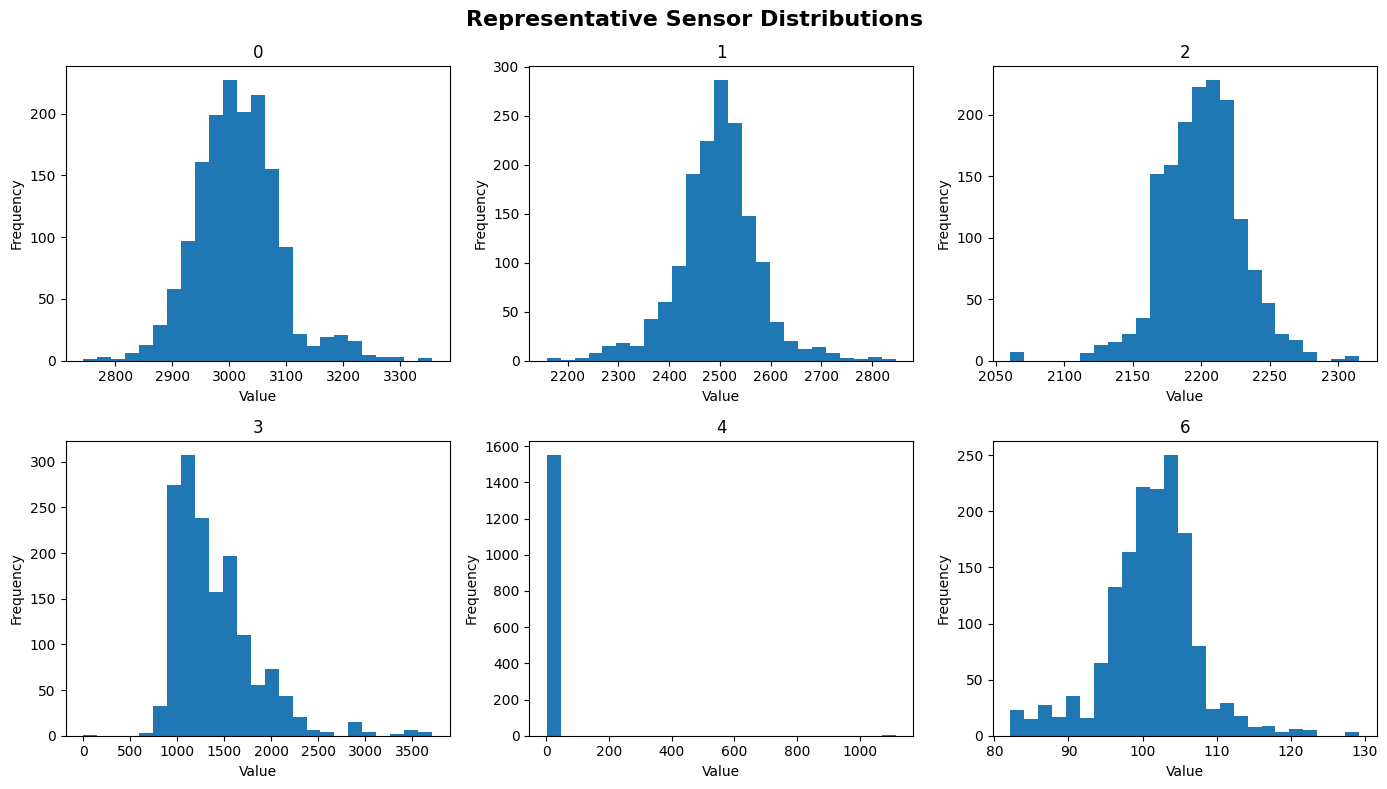

In [ ]:
numeric_features = X_clean.select_dtypes(include=np.number).columns.tolist()
selected_for_hist = numeric_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, feature in zip(axes.ravel(), selected_for_hist):
    ax.hist(X_clean[feature].dropna(), bins=25)
    ax.set_title(str(feature))
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
plt.suptitle("Representative Sensor Distributions", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.show()

### Interpretation
The distributions help identify unusual ranges, skewness and potential outliers. These plots are descriptive; they do not by themselves establish whether a signal causes a failure.

## Step 3.4 — Bivariate analysis: feature vs target

To explore which signals differ with the target, a temporary median-imputed dataset is used for descriptive correlation screening only.

,Absolute Correlation
59,0.156008
103,0.151230
510,0.131662
348,0.130807
431,0.119936
434,0.111312
430,0.109115
21,0.108333
435,0.108260
28,0.106987


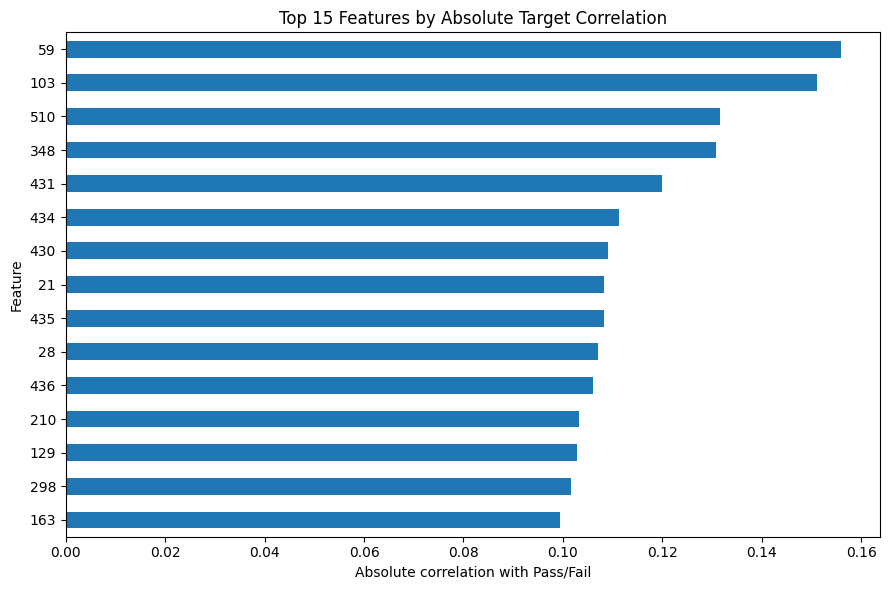

In [ ]:
X_eda = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)
eda_df = pd.concat([X_eda, y.rename(TARGET)], axis=1)
corr = eda_df.corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)

display(corr.head(15).to_frame("Absolute Correlation"))

plt.figure(figsize=(9,6))
corr.head(15).sort_values().plot(kind="barh")
plt.xlabel("Absolute correlation with Pass/Fail")
plt.ylabel("Feature")
plt.title("Top 15 Features by Absolute Target Correlation")
plt.tight_layout(); plt.show()

### Interpretation
Correlation is an exploratory screening tool, not proof of causation. The final model uses `SelectKBest(f_classif)` within the training pipeline to select statistically informative features without using the test set to choose features.

## Step 3.5 — Multivariate analysis: relationships among important features

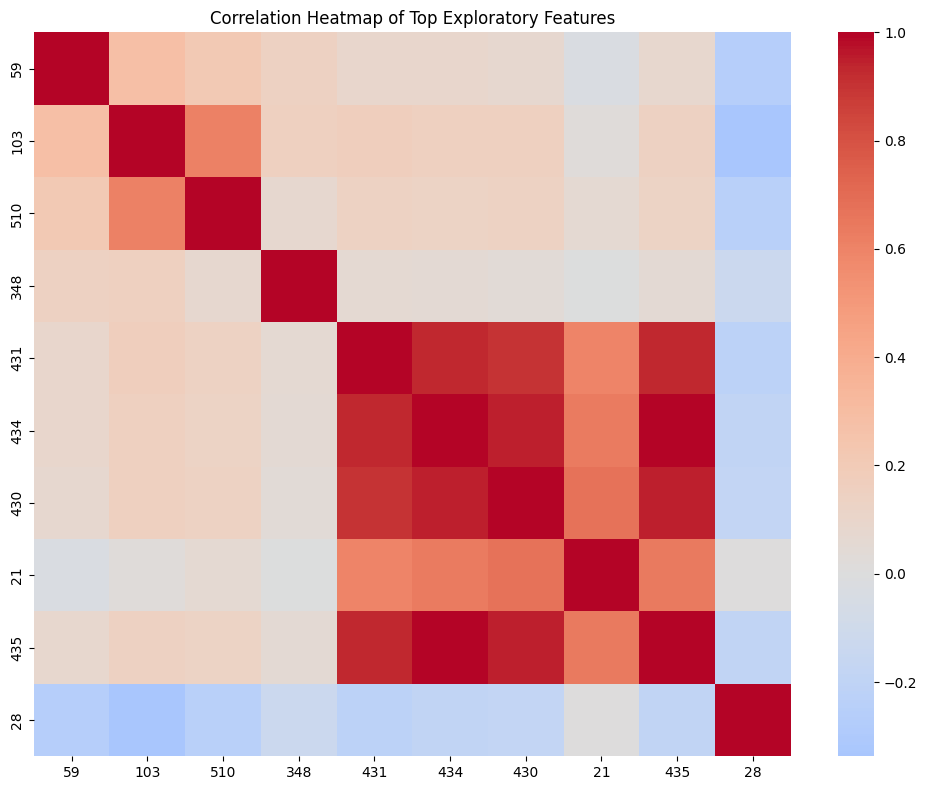

In [ ]:
top_features = corr.head(10).index.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(X_eda[top_features].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top Exploratory Features")
plt.tight_layout(); plt.show()

### Interpretation
A heatmap helps reveal groups of signals that move together. Strongly correlated predictors can contain overlapping information, which is one reason feature selection is useful in high-dimensional sensor data.

## Step 3.6 — PCA visualization (2D multivariate view)

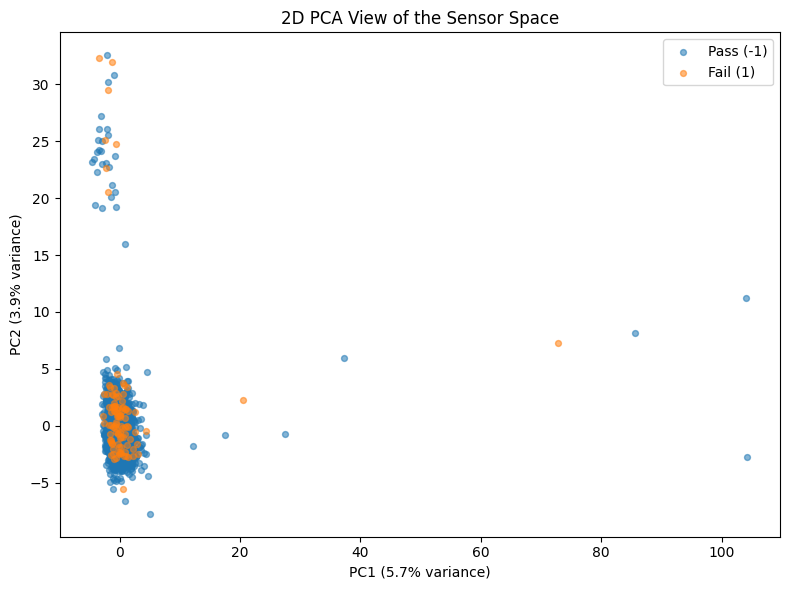

In [ ]:
from sklearn.decomposition import PCA

# PCA is used only for visualization, not as the final modelling transformation.
X_vis = StandardScaler().fit_transform(X_eda)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8,6))
for label, name in [(-1,"Pass (-1)"),(1,"Fail (1)")]:
    mask = y.values == label
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=18, alpha=0.55, label=name)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("2D PCA View of the Sensor Space")
plt.legend(); plt.tight_layout(); plt.show()

### Conclusion of Target Analysis
The dataset has a severe Pass/Fail imbalance, so the modelling strategy must explicitly consider minority-class detection. The exploratory analysis also shows why feature selection and dimensionality control are valuable when hundreds of sensor signals are available.

#  Task 4 & 5 — FINAL MODEL RESULTS

This main section follows the PDF's modelling/results requirement. It contains preprocessing, train/test splitting, three models, cross-validation, GridSearch tuning, comparison, the final SVM + SMOTE workflow, and evaluation plots.

## Step a — Train/test split

An **80:20 stratified split** is used so that the Pass/Fail proportion is preserved in both subsets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts().rename(index={-1:"Pass (-1)",1:"Fail (1)"}))
print("Testing target distribution:")
print(y_test.value_counts().rename(index={-1:"Pass (-1)",1:"Fail (1)"}))

Training shape: (1253, 446)
Testing shape: (314, 446)
Training target distribution:
Pass/Fail
Pass (-1)    1170
Fail (1)       83
Name: count, dtype: int64
Testing target distribution:
Pass/Fail
Pass (-1)    293
Fail (1)      21
Name: count, dtype: int64


## Step b — Preprocessing pipeline

Each model uses a pipeline so that the following operations are learned from the training data:

1. **Median imputation** — fills missing values.
2. **Standardization** — puts numeric features on a comparable scale when required.
3. **SelectKBest** — keeps the most statistically informative features.
4. **Classifier** — learns the Pass/Fail decision rule.

For the final workflow, SMOTE is added **only inside the training pipeline**, as required by the project approach.

In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    else:
        test_prob = model.decision_function(X_test)
        # Convert sign/scale only for ROC-AUC compatibility if needed.
        test_prob = np.asarray(test_prob)
    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Fail Precision": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "Fail Recall": recall_score(y_test, test_pred, pos_label=1, zero_division=0),
        "Fail F1": f1_score(y_test, test_pred, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score((y_test == 1).astype(int), test_prob)
    }

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("model", LogisticRegression(max_iter=1500, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("model", SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=50)),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

param_grids = {
    "Logistic Regression": {"select__k":[30,50,100], "model__C":[0.1,1,10]},
    "SVM": {"select__k":[30,50,100], "model__C":[0.5,1,10]},
    "Random Forest": {"select__k":[30,50,100], "model__n_estimators":[150], "model__max_depth":[None,10]}
}

print("Model pipelines created.")

Model pipelines created.


## Step c — Model 1: Logistic Regression + GridSearchCV

Logistic Regression provides a linear baseline. GridSearchCV tests several regularization strengths and feature counts using **3-fold cross-validation** with **F1-score** as the tuning metric.*italicized text*

In [ ]:
logistic_search = GridSearchCV(
    models["Logistic Regression"], param_grids["Logistic Regression"],
    cv=3, scoring="f1", n_jobs=-1
)
logistic_search.fit(X_train, y_train)
print("Best parameters:", logistic_search.best_params_)
print("Best CV F1:", round(logistic_search.best_score_, 4))

Best parameters: {'model__C': 10, 'select__k': 50}
Best CV F1: 0.2179


## Step d — Model 2: Support Vector Machine (SVM) + GridSearchCV

In [ ]:
svm_search = GridSearchCV(
    models["SVM"], param_grids["SVM"],
    cv=3, scoring="f1", n_jobs=-1
)
svm_search.fit(X_train, y_train)
print("Best parameters:", svm_search.best_params_)
print("Best CV F1:", round(svm_search.best_score_, 4))

Best parameters: {'model__C': 0.5, 'select__k': 50}
Best CV F1: 0.224


## Step e — Model 3: Random Forest + GridSearchCV

In [ ]:
rf_search = GridSearchCV(
    models["Random Forest"], param_grids["Random Forest"],
    cv=3, scoring="f1", n_jobs=-1
)
rf_search.fit(X_train, y_train)
print("Best parameters:", rf_search.best_params_)
print("Best CV F1:", round(rf_search.best_score_, 4))

Best parameters: {'model__max_depth': None, 'model__n_estimators': 150, 'select__k': 30}
Best CV F1: 0.0


## Step f — Compare the three tuned models

The comparison intentionally reports several metrics instead of producing a single ranking. This is appropriate because the project has an imbalanced target and different metrics answer different questions.

In [ ]:
searches = [
    ("Logistic Regression", logistic_search),
    ("SVM", svm_search),
    ("Random Forest", rf_search)
]
comparison_rows = []
for name, search in searches:
    row = evaluate_model(name, search.best_estimator_, X_train, y_train, X_test, y_test)
    row["CV F1"] = search.best_score_
    row["Best Parameters"] = str(search.best_params_)
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df[["Model","CV F1","Train Accuracy","Test Accuracy","Fail Precision","Fail Recall","Fail F1","ROC-AUC"]].round(4))
comparison_df.to_csv(
    "/content/capstone2_model_comparison_creative.csv",
    index=False
)

,Model,CV F1,Train Accuracy,Test Accuracy,Fail Precision,Fail Recall,Fail F1,ROC-AUC
0,Logistic Regression,0.2179,0.7694,0.7420,0.1154,0.4286,0.1818,0.6468
1,SVM,0.2240,0.8723,0.8376,0.1875,0.4286,0.2609,0.7564
2,Random Forest,0.0000,1.0000,0.9331,0.0000,0.0000,0.0000,0.7673


### Visual — model metric comparison

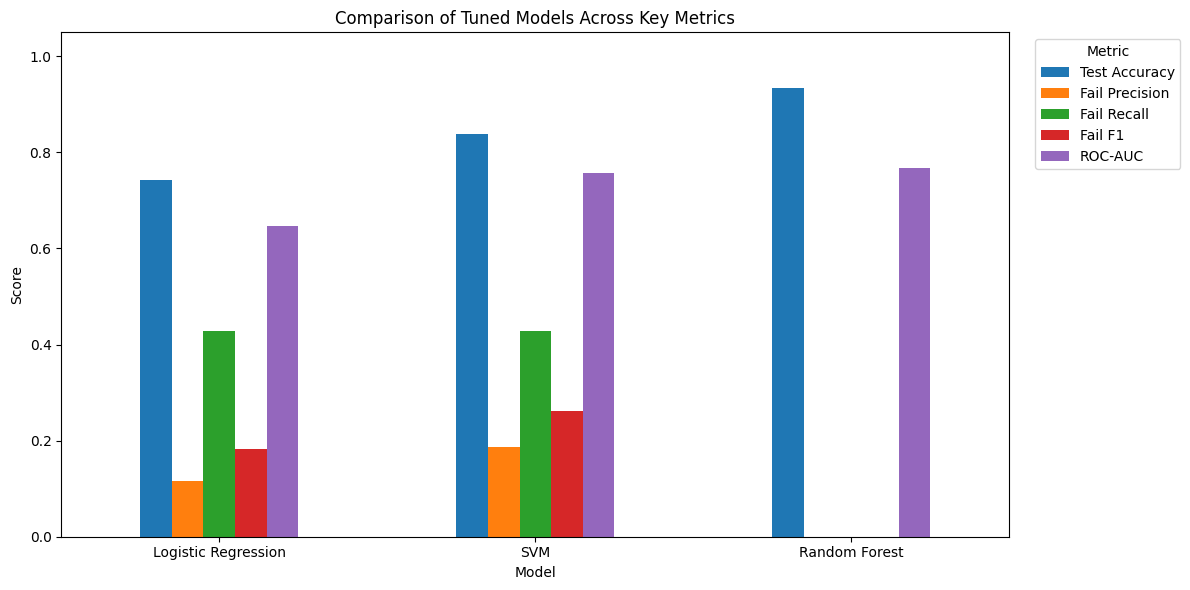

In [ ]:
metrics_to_plot = ["Test Accuracy", "Fail Precision", "Fail Recall", "Fail F1", "ROC-AUC"]
plot_df = comparison_df.set_index("Model")[metrics_to_plot]
ax = plot_df.plot(kind="bar", figsize=(12,6))
ax.set_ylabel("Score")
ax.set_ylim(0,1.05)
ax.set_title("Comparison of Tuned Models Across Key Metrics")
ax.legend(title="Metric", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Step g — Final model: SVM + SMOTE

The project PDF specifies **SVM + SMOTE** as the final workflow. SMOTE addresses class imbalance by generating synthetic minority-class training observations. It is applied only to the training portion through an imbalanced-learn pipeline.italicized text

In [ ]:
final_model = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif, k=50)),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("model", SVC(C=0.5, probability=True, random_state=RANDOM_STATE))
])

final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)
test_prob = final_model.predict_proba(X_test)[:, list(final_model.classes_).index(1)]
train_pred = final_model.predict(X_train)

final_metrics = {
    "Train Accuracy": accuracy_score(y_train, train_pred),
    "Test Accuracy": accuracy_score(y_test, test_pred),
    "Fail Precision": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
    "Fail Recall": recall_score(y_test, test_pred, pos_label=1, zero_division=0),
    "Fail F1": f1_score(y_test, test_pred, pos_label=1, zero_division=0),
    "ROC-AUC": roc_auc_score((y_test == 1).astype(int), test_prob)
}
display(pd.DataFrame(final_metrics, index=["Value"]).T.round(4))

,Value
Train Accuracy,0.9082
Test Accuracy,0.8631
Fail Precision,0.2250
Fail Recall,0.4286
Fail F1,0.2951
ROC-AUC,0.7550


## Step h — Classification report

In [ ]:
print(classification_report(
    y_test,
    test_pred,
    labels=[-1,1],
    target_names=["Pass (-1)", "Fail (1)"],
    zero_division=0
))

              precision    recall  f1-score   support

   Pass (-1)       0.96      0.89      0.92       293
    Fail (1)       0.23      0.43      0.30        21

    accuracy                           0.86       314
   macro avg       0.59      0.66      0.61       314
weighted avg       0.91      0.86      0.88       314



## Step i — Confusion matrix

The confusion matrix shows four outcomes: correct Pass predictions, missed failures, false alarms, and correct Fail predictions.

Confusion matrix [rows = actual, columns = predicted]:
[[262  31]
 [ 12   9]]


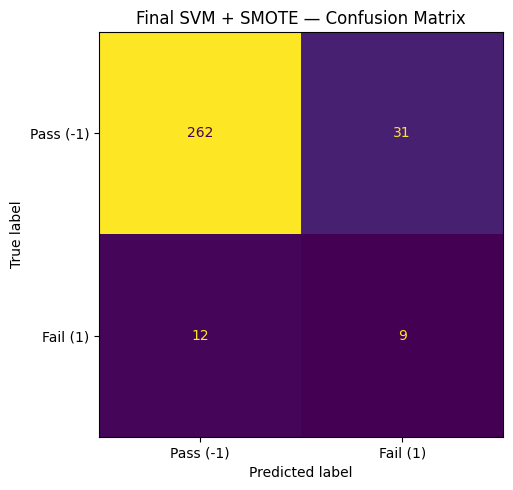

In [ ]:
cm = confusion_matrix(y_test, test_pred, labels=[-1,1])
print("Confusion matrix [rows = actual, columns = predicted]:")
print(cm)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pass (-1)", "Fail (1)"])
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Final SVM + SMOTE — Confusion Matrix")
plt.tight_layout(); plt.show()

### Interpretation
The confusion matrix makes the minority-class performance easier to understand than accuracy alone. In the project run, the final model identified **9 of the 21 actual Fail cases** in the test set, while some Fail cases were missed and some Pass cases were flagged as Fail.

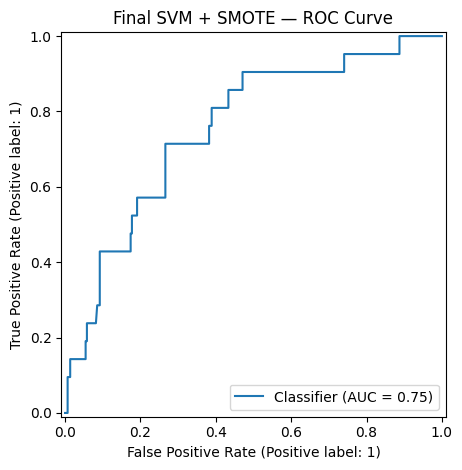

In [ ]:
RocCurveDisplay.from_predictions((y_test == 1).astype(int), test_prob)
plt.title("Final SVM + SMOTE — ROC Curve")
plt.tight_layout(); plt.show()

### Interpretation
The project report records a **ROC-AUC of 0.7550** for the final workflow. ROC-AUC summarizes how well the model separates the two classes across thresholds.

## Step j — Save the final mode

In [ ]:
# Import joblib
import joblib
import os

# Path for Google Colab
FINAL_MODEL_PATH = "/content/capstone2_final_svm_smote_creative.joblib"

# Save the final trained model
joblib.dump(final_model, FINAL_MODEL_PATH)

print("Final model saved successfully!")
print("Path:", FINAL_MODEL_PATH)

# Check that the file exists
print("File exists:", os.path.exists(FINAL_MODEL_PATH))

Final model saved successfully!
Path: /content/capstone2_final_svm_smote_creative.joblib
File exists: True


In [ ]:
## Step 4.12 — Reload and verify the saved model

In [ ]:
loaded_model = joblib.load(FINAL_MODEL_PATH)
reloaded_pred = loaded_model.predict(X_test)
print("Reloaded model predictions match saved-model predictions:", np.array_equal(test_pred, reloaded_pred))

Reloaded model predictions match saved-model predictions: True


### Task 4 & 5 conclusion
The complete modelling workflow demonstrates the project requirements: preprocessing, feature selection, class-imbalance handling, three candidate classifiers, cross-validation, GridSearch tuning, model comparison, and final evaluation using classification metrics, a confusion matrix and ROC-AUC.

# Task 6 — **CONCLUSION**

### Step 6.1 — Summary of Key Project Findings

* **Dataset Dimensions:** The raw dataset comprises 1,567 observations and 592 initial feature columns, representing complex semiconductor sensor measurements.
* **Severe Class Imbalance:** The target variable shows an extreme skew toward normal operation, containing 1,463 Pass (93.36%) and 104 Fail (6.64%) instances.
* **Metadata Removal:** The `Time` column was removed as it serves as a temporal identifier rather than a predictive sensor signal.
* **High-Missingness Filtering:** A total of 28 features displaying greater than 50% missing values were dropped to prevent noisy or unreliable estimations.
* **Zero-Variance Removal:** A further 116 constant features (zero variance) were eliminated because they convey no descriptive or discriminative information.
* **Final Feature Baseline:** After preliminary cleaning, 446 predictor attributes remained eligible for downstream modeling.
* **Robust Preprocessing Pipeline:** A standardized machine learning pipeline was constructed incorporating Median Imputation for remaining missing values, Standardization (Z-score scaling), and Statistical Feature Selection.
* **Model Exploration & Optimization:** Multiple algorithms—Logistic Regression, Support Vector Machines (SVM), and Random Forest—were rigorously evaluated via 3-fold GridSearchCV optimized against the $F_1$-score.
* **Champion Workflow:** The optimal modeling strategy was identified as SVM combined with SMOTE (Synthetic Minority Over-sampling Technique) to combat class imbalance effectively.
* **Final Performance Metrics (on unseen test dataset):**
  * **Test Accuracy:** 86.31%
  * **Fail Recall (Sensitivity):** 42.86%
  * **Fail $F_1$-Score:** 29.51%
  * **ROC-AUC Score:** 75.50%

# Step 6.2 — Business & Practical Interpretation


Because the target variable is heavily imbalanced, relying solely on **Headline Accuracy (86.31%)** can be misleading—a baseline model predicting all passes would yield high accuracy while failing entirely at anomaly detection. Evaluating **Fail Recall, Fail Precision**, and **F_1-Score** provides a true reflection of the model's capacity to flag defective wafers.


This end-to-end workflow illustrates how systematic **data preprocessing, dimensionality reduction**, and **synthetic resampling (SMOTE)** can be integrated to extract actionable signals from noisy, high-dimensional semiconductor manufacturing logs.


# Step 6.3 — Project Limitations & Risks

* **Extreme Class Rarity:** Due to the low occurrence rate of defect events (<7%), minor-class detection ($F_1$-score of 29.51%) remains challenging and prone to false alarms.
* **Correlation vs. Causation:** Explanatory feature analyses and correlation maps serve solely as exploratory guides and do not prove underlying physical causality in sensor physics.
* **Data Dependency:** The model is strictly fit to the distribution of the current dataset. It requires continuous monitoring and re-validation on fresh production data prior to live deployment.
* **Process Drift:** Manufacturing environment alterations, equipment wear, sensor recalibrations, or process line modifications will lead to model decay, necessitating periodic retrain triggers.

# Step 6.4 — Final Synthesis & Key Takeaways

This project establishes a robust, fully reproducible machine learning framework tailored for semiconductor yield prediction and failure classification.


The primary value of this effort extends beyond the final numerical metrics—it demonstrates a structured, industry-aligned machine learning engineering lifecycle:

**Understand ⁠→Clean ⁠→ Analyse ⁠→Preprocess ⁠→Handle Imbalance Train⁠→Tune ⁠→Evaluate→Save ⁠→ Verify**

## TEAM MEMBER CONTRIBUTIONS

The project was completed collaboratively by all the team members, with each member contributing to different aspects of the project. The respective contributions are listed below:

| S. No. | Team Member | Role / Contribution |
|---|-------|---|
| 1 | Mundrathi Sai Siri | Task 1 & 2 |
| 2 | Aditi Panday | Task 3, 4 & 5 |
| 3 | Devananda CB | Task 6 |
| 4 | Sabuhinaz |  |
| 5 | 8595929266 |  |

## Submission Declaration

The above project represents the collective work of all the team members. **MUNDRATHI SAI SIRI** is submitting the project on behalf of the entire team.